Avaliar o desempenho dos modelos com métricas.

Interpretar os resultados, incluindo a importância das variáveis.

Criar uma conclusão estratégica apontando os principais fatores que influenciam a evasão.

# Importação de Bibliotecas utilizadas neste notebook

In [223]:
# Dados
import pandas as pd

# Cálculos
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier    # KNN
from sklearn.preprocessing import MinMaxScaler        # Utilizado para normalização
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.linear_model import LogisticRegression


# Preparação dos Dados

## Carga de Dados - Obtenção do Arquivo Tratado

In [123]:
# Obter dados já tratados em Desafio Telecom X - parte 1
dados = pd.read_csv('https://raw.githubusercontent.com/Ronaldo-Pardini/TelecomX_parte2/refs/heads/main/Dados_TelecomX_tratados.csv')
dados.head(3)

,customerID,Churn,Gênero,Cliente Senior,Possui parceiro(a),Possui Dependentes,Meses de Contrato,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo de Contrato,Conta Digital,Método de Pagamento,Gasto Mensal,Gasto Total,Gasto Diário
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,...,False,True,True,False,One year,True,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,...,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,...,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85,2.46


## Remoção de Colunas Irrelevantes

In [124]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7043 non-null   object 
 1   Churn                7043 non-null   bool   
 2   Gênero               7043 non-null   object 
 3   Cliente Senior       7043 non-null   bool   
 4   Possui parceiro(a)   7043 non-null   bool   
 5   Possui Dependentes   7043 non-null   bool   
 6   Meses de Contrato    7043 non-null   int64  
 7   PhoneService         7043 non-null   bool   
 8   MultipleLines        7043 non-null   bool   
 9   InternetService      7043 non-null   object 
 10  OnlineSecurity       7043 non-null   bool   
 11  OnlineBackup         7043 non-null   bool   
 12  DeviceProtection     7043 non-null   bool   
 13  TechSupport          7043 non-null   bool   
 14  StreamingTV          7043 non-null   bool   
 15  StreamingMovies      7043 non-null   b

In [125]:
# Excluir colunas que não serão parte do estudo
dados.drop(columns=['customerID'], inplace=True)

In [126]:
# Avaliar conteúdo das colunas
Lista = []

for col in dados.columns:
  print(f'{col}: {dados[col].nunique()}')
  if dados[col].nunique() < 50:
    print(dados[col].unique())
  else:
    Lista.append(col)
    print('Muitos registros únicos para imprimir.')
  print('-' * 50)

dados[Lista].describe()


Churn: 2
[False  True]
--------------------------------------------------
Gênero: 2
['Female' 'Male']
--------------------------------------------------
Cliente Senior: 2
[False  True]
--------------------------------------------------
Possui parceiro(a): 2
[ True False]
--------------------------------------------------
Possui Dependentes: 2
[ True False]
--------------------------------------------------
Meses de Contrato: 73
Muitos registros únicos para imprimir.
--------------------------------------------------
PhoneService: 2
[ True False]
--------------------------------------------------
MultipleLines: 2
[False  True]
--------------------------------------------------
InternetService: 3
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity: 2
[False  True]
--------------------------------------------------
OnlineBackup: 2
[ True False]
--------------------------------------------------
DeviceProtection: 2
[False  True]
--------------------

,Meses de Contrato,Gasto Mensal,Gasto Total,Gasto Diário
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158675
std,24.559481,30.090047,2266.794470,1.003088
min,0.000000,18.250000,0.000000,0.610000
25%,9.000000,35.500000,398.550000,1.180000
50%,29.000000,70.350000,1394.550000,2.340000
75%,55.000000,89.850000,3786.600000,2.990000
max,72.000000,118.750000,8684.800000,3.960000


## Transformação de Dados

### Transformação de Campos Booleanos com True/False para formato numérico 0/1

In [127]:
colunas_booleanas = dados.select_dtypes(include='bool').columns

# Em todas as colunas booleanas, trocar True por 1 e False por 0
dados[colunas_booleanas] = dados[colunas_booleanas].astype(int)
dados.head(3)

,Churn,Gênero,Cliente Senior,Possui parceiro(a),Possui Dependentes,Meses de Contrato,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo de Contrato,Conta Digital,Método de Pagamento,Gasto Mensal,Gasto Total,Gasto Diário
0,0,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46


### Transformação de Campos Categóricos para formato numérico
Transformando as variáveis categóricas em formato numérico para torná-las compatíveis com algoritmos de machine learning.

In [128]:
# Carregar variável alvo e explicativas
X = dados.drop(columns=['Churn'], axis=1)
y = dados['Churn']

In [129]:
# Guardar nomes originais das colunas
colunas = X.columns
colunas_categoricas = list(X.select_dtypes(include='object').columns)
colunas_categoricas

['Gênero', 'InternetService', 'Tipo de Contrato', 'Método de Pagamento']

In [130]:
# Transformando as variáveis explicativas CATEGÓRICAS com OneHotEncoder
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['Gênero', 'InternetService', 'Tipo de Contrato', 'Método de Pagamento']
),
    remainder = 'passthrough',
    sparse_threshold=0)

X = one_hot.fit_transform(X)

In [131]:
# Visualizar como ficaram os nomes das colunas
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__Gênero_Male', 'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__InternetService_No',
       'onehotencoder__Tipo de Contrato_Month-to-month',
       'onehotencoder__Tipo de Contrato_One year',
       'onehotencoder__Tipo de Contrato_Two year',
       'onehotencoder__Método de Pagamento_Bank transfer (automatic)',
       'onehotencoder__Método de Pagamento_Credit card (automatic)',
       'onehotencoder__Método de Pagamento_Electronic check',
       'onehotencoder__Método de Pagamento_Mailed check',
       'remainder__Cliente Senior', 'remainder__Possui parceiro(a)',
       'remainder__Possui Dependentes', 'remainder__Meses de Contrato',
       'remainder__PhoneService', 'remainder__MultipleLines',
       'remainder__OnlineSecurity', 'remainder__OnlineBackup',
       'remainder__DeviceProtection', 'remainder__TechSupport',
       'remainder__StreamingTV', 'remainder__StreamingMovies',
       'remainde

In [132]:
# Visualizar resultados da transformação em formato DataFrame para CONFERÊNCIA
dados_tratados = pd.DataFrame(X, columns = one_hot.get_feature_names_out(colunas))
dados_tratados['Churn'] = y
dados_tratados.head(3)

,onehotencoder__Gênero_Male,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__Tipo de Contrato_Month-to-month,onehotencoder__Tipo de Contrato_One year,onehotencoder__Tipo de Contrato_Two year,onehotencoder__Método de Pagamento_Bank transfer (automatic),onehotencoder__Método de Pagamento_Credit card (automatic),onehotencoder__Método de Pagamento_Electronic check,...,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__StreamingTV,remainder__StreamingMovies,remainder__Conta Digital,remainder__Gasto Mensal,remainder__Gasto Total,remainder__Gasto Diário,Churn
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30,2.19,0
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40,2.00,0
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85,2.46,1


## Verificação da Proporção de Evasão

Calcule a proporção de clientes que evadiram em relação aos que permaneceram ativos. Avalie se há desequilíbrio entre as classes, o que pode impactar modelos preditivos e a análise de resultados.

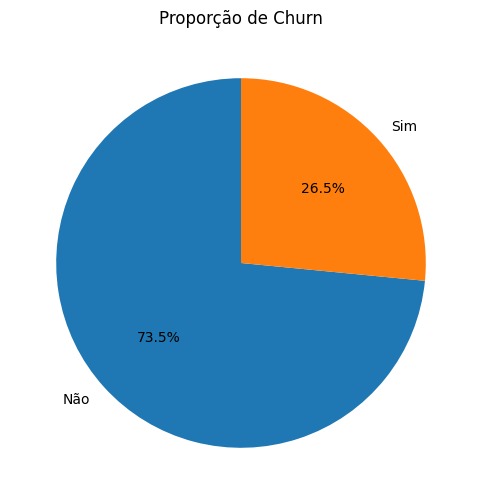

In [133]:
# Calcula proporções
proporcao = dados['Churn'].value_counts(normalize=True)

# Ajusta os rótulos
labels = ['Não', 'Sim']

# Gráfico de pizza
plt.figure(figsize=(6,6))
plt.pie(
    proporcao,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Proporção de Churn')
plt.show()

Dados levemente desbalanceados, utilizarei o parâmetro "stratify" ao realizar a separação dos dados em Treino e Teste para ajustar os modelos.  Não vejo necessidade de aplicar undersampling ou oversampling neste estudo.

# Correlação e Seleção de Variáveis

## Análise de Correlação

In [134]:
correlacao_churn = dados_tratados.corr(method='pearson').loc['Churn', :].sort_values(ascending=False)

# Selecionar apenas as variáveis explicativas com correlação absoluta > 0.1
V_explicativas_utilizar = list(correlacao_churn[abs(correlacao_churn) > 0.1].index)
V_explicativas_descartadas = list(correlacao_churn[abs(correlacao_churn) <= 0.1].index)
V_explicativas_utilizar.pop(0)    # Excluir a variável alvo "Churn"
V_explicativas_utilizar

print(correlacao_churn[abs(correlacao_churn) > 0.1])

Churn                                                           1.000000
onehotencoder__Tipo de Contrato_Month-to-month                  0.405103
onehotencoder__InternetService_Fiber optic                      0.308020
onehotencoder__Método de Pagamento_Electronic check             0.301919
remainder__Gasto Diário                                         0.193412
remainder__Gasto Mensal                                         0.193356
remainder__Conta Digital                                        0.191825
remainder__Cliente Senior                                       0.150889
onehotencoder__Método de Pagamento_Bank transfer (automatic)   -0.117937
onehotencoder__InternetService_DSL                             -0.124214
onehotencoder__Método de Pagamento_Credit card (automatic)     -0.134302
remainder__Possui parceiro(a)                                  -0.150448
remainder__Possui Dependentes                                  -0.164221
remainder__TechSupport                             

In [135]:
V_explicativas_descartadas

['remainder__StreamingTV',
 'remainder__StreamingMovies',
 'remainder__MultipleLines',
 'remainder__PhoneService',
 'onehotencoder__Gênero_Male',
 'remainder__DeviceProtection',
 'remainder__OnlineBackup',
 'onehotencoder__Método de Pagamento_Mailed check']

In [136]:
# Avaliar correlação entre as Variáveis explicativas selecionadas para o estudo

# Destacar variáveis com correlação maior ou igual a 0.80
corr = dados_tratados[V_explicativas_utilizar].corr(method='pearson')

corr.style.applymap(
    lambda v: 'color: red; font-weight: bold'
    if abs(v) >= 0.8 and v != 1
    else ''
)

/tmp/ipython-input-3781169062.py:6: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



,onehotencoder__Tipo de Contrato_Month-to-month,onehotencoder__InternetService_Fiber optic,onehotencoder__Método de Pagamento_Electronic check,remainder__Gasto Diário,remainder__Gasto Mensal,remainder__Conta Digital,remainder__Cliente Senior,onehotencoder__Método de Pagamento_Bank transfer (automatic),onehotencoder__InternetService_DSL,onehotencoder__Método de Pagamento_Credit card (automatic),remainder__Possui parceiro(a),remainder__Possui Dependentes,remainder__TechSupport,remainder__OnlineSecurity,onehotencoder__Tipo de Contrato_One year,remainder__Gasto Total,onehotencoder__InternetService_No,onehotencoder__Tipo de Contrato_Two year,remainder__Meses de Contrato
onehotencoder__Tipo de Contrato_Month-to-month,1.000000,0.244164,0.331661,0.060235,0.060165,0.169096,0.138360,-0.179707,-0.065509,-0.204145,-0.280865,-0.231720,-0.285241,-0.246679,-0.568744,-0.444255,-0.218639,-0.622633,-0.645561
onehotencoder__InternetService_Fiber optic,0.244164,1.000000,0.336410,0.787091,0.787066,0.326853,0.255338,-0.022624,-0.640987,-0.050077,0.000304,-0.165818,-0.020492,-0.030696,-0.076324,0.361655,-0.465793,-0.211526,0.019720
onehotencoder__Método de Pagamento_Electronic check,0.331661,0.336410,1.000000,0.271650,0.271625,0.208865,0.171718,-0.376762,-0.104418,-0.373322,-0.083852,-0.150642,-0.114839,-0.112338,-0.109130,-0.059246,-0.284917,-0.282138,-0.208363
remainder__Gasto Diário,0.060235,0.787091,0.271650,1.000000,0.999996,0.352135,0.220147,0.042785,-0.160211,0.030547,0.096909,-0.113939,0.338300,0.296591,0.004849,0.651189,-0.763562,-0.074710,0.247910
remainder__Gasto Mensal,0.060165,0.787066,0.271625,0.999996,1.000000,0.352150,0.220173,0.042812,-0.160189,0.030550,0.096848,-0.113890,0.338304,0.296594,0.004904,0.651174,-0.763557,-0.074681,0.247900
remainder__Conta Digital,0.169096,0.326853,0.208865,0.352135,0.352150,1.000000,0.156530,-0.016332,-0.063121,-0.013589,-0.014877,-0.111377,0.037880,-0.003636,-0.051391,0.158574,-0.321013,-0.147889,0.006152
remainder__Cliente Senior,0.138360,0.255338,0.171718,0.220147,0.220173,0.156530,1.000000,-0.016159,-0.108322,-0.024135,0.016479,-0.211185,-0.060625,-0.038653,-0.046262,0.103006,-0.182742,-0.117000,0.016567
onehotencoder__Método de Pagamento_Bank transfer (automatic),-0.179707,-0.022624,-0.376762,0.042785,0.042812,-0.016332,-0.016159,1.000000,0.025476,-0.278215,0.110706,0.052021,0.101252,0.095158,0.057451,0.185987,-0.002113,0.154471,0.243510
onehotencoder__InternetService_DSL,-0.065509,-0.640987,-0.104418,-0.160211,-0.160189,-0.063121,-0.108322,0.025476,1.000000,0.051438,-0.000851,0.052010,0.313118,0.321269,0.046795,-0.052469,-0.380635,0.031714,0.013274
onehotencoder__Método de Pagamento_Credit card (automatic),-0.204145,-0.050077,-0.373322,0.030547,0.030550,-0.013589,-0.024135,-0.278215,0.051438,1.000000,0.082029,0.060267,0.117272,0.115721,0.067589,0.182915,0.001030,0.173265,0.233006


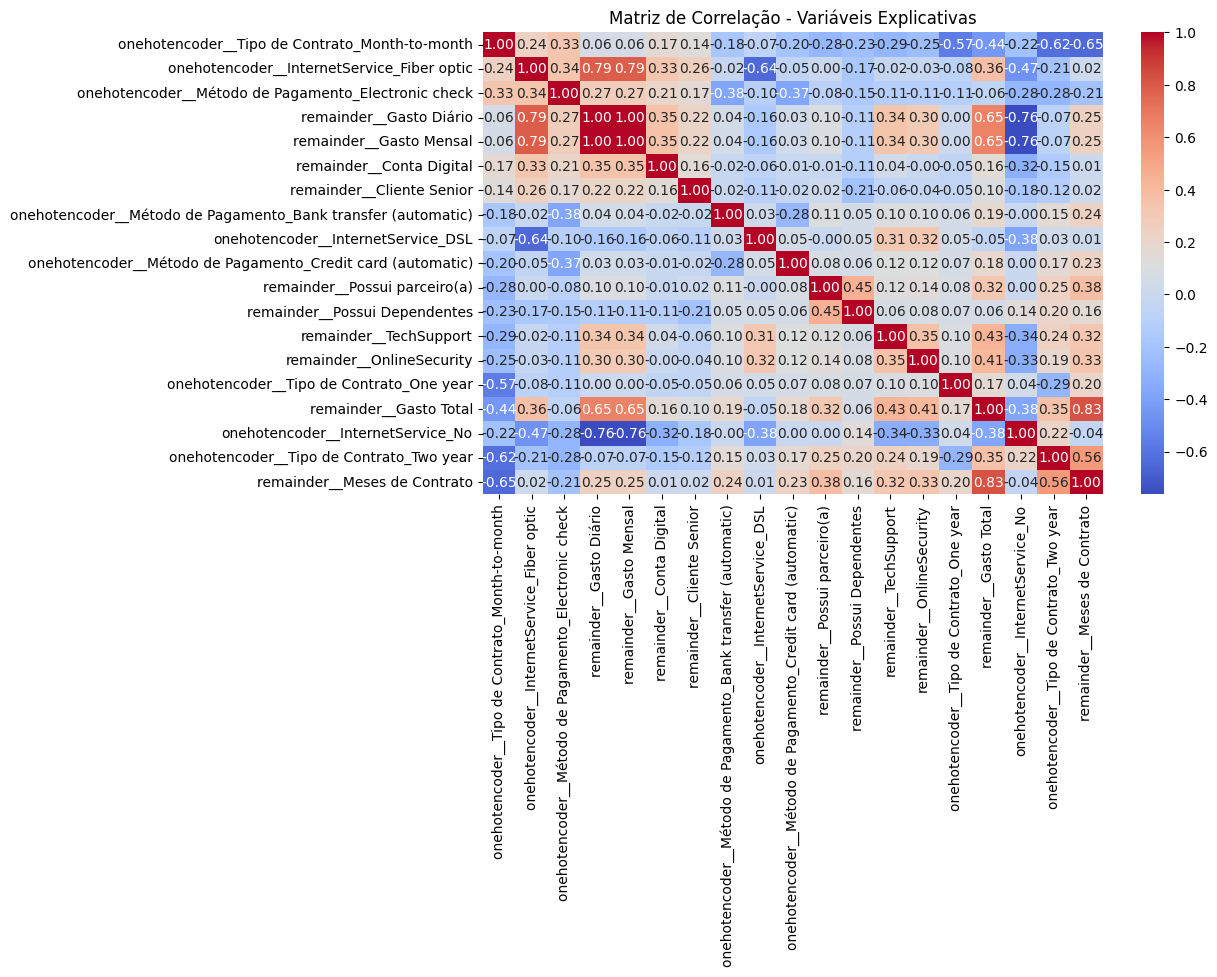

In [137]:
# Visualizar em formato heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação - Variáveis Explicativas")
plt.show()

Mediante os resultados acima, excluiremos do estudo as variáveis:
- remainder__Gasto Total
- remainder__Gasto Diário

A variável remainder_Gasto Mensal será mantida.

In [138]:
# Excluir variáveis por alta correlação entre si
V_excluir = ['remainder__Gasto Total', 'remainder__Gasto Diário']
V_explicativas_utilizar = [x for x in V_explicativas_utilizar if x not in V_excluir]

# Incluir as variáveis na lista de excluídas
V_explicativas_descartadas.extend(V_excluir)

### ATENÇÃO
Correlações entre variáveis explicativas acima de 0.70.  Avaliar se vale a pena excluir também

In [139]:
# Avaliar correlação entre as Variáveis explicativas selecionadas para o estudo

# Destacar variáveis com correlação maior ou igual a 0.70
corr = dados_tratados[V_explicativas_utilizar].corr(method='pearson')

corr.style.applymap(
    lambda v: 'color: red; font-weight: bold'
    if abs(v) >= 0.7 and v != 1
    else ''
)

/tmp/ipython-input-4050870975.py:6: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



,onehotencoder__Tipo de Contrato_Month-to-month,onehotencoder__InternetService_Fiber optic,onehotencoder__Método de Pagamento_Electronic check,remainder__Gasto Mensal,remainder__Conta Digital,remainder__Cliente Senior,onehotencoder__Método de Pagamento_Bank transfer (automatic),onehotencoder__InternetService_DSL,onehotencoder__Método de Pagamento_Credit card (automatic),remainder__Possui parceiro(a),remainder__Possui Dependentes,remainder__TechSupport,remainder__OnlineSecurity,onehotencoder__Tipo de Contrato_One year,onehotencoder__InternetService_No,onehotencoder__Tipo de Contrato_Two year,remainder__Meses de Contrato
onehotencoder__Tipo de Contrato_Month-to-month,1.000000,0.244164,0.331661,0.060165,0.169096,0.138360,-0.179707,-0.065509,-0.204145,-0.280865,-0.231720,-0.285241,-0.246679,-0.568744,-0.218639,-0.622633,-0.645561
onehotencoder__InternetService_Fiber optic,0.244164,1.000000,0.336410,0.787066,0.326853,0.255338,-0.022624,-0.640987,-0.050077,0.000304,-0.165818,-0.020492,-0.030696,-0.076324,-0.465793,-0.211526,0.019720
onehotencoder__Método de Pagamento_Electronic check,0.331661,0.336410,1.000000,0.271625,0.208865,0.171718,-0.376762,-0.104418,-0.373322,-0.083852,-0.150642,-0.114839,-0.112338,-0.109130,-0.284917,-0.282138,-0.208363
remainder__Gasto Mensal,0.060165,0.787066,0.271625,1.000000,0.352150,0.220173,0.042812,-0.160189,0.030550,0.096848,-0.113890,0.338304,0.296594,0.004904,-0.763557,-0.074681,0.247900
remainder__Conta Digital,0.169096,0.326853,0.208865,0.352150,1.000000,0.156530,-0.016332,-0.063121,-0.013589,-0.014877,-0.111377,0.037880,-0.003636,-0.051391,-0.321013,-0.147889,0.006152
remainder__Cliente Senior,0.138360,0.255338,0.171718,0.220173,0.156530,1.000000,-0.016159,-0.108322,-0.024135,0.016479,-0.211185,-0.060625,-0.038653,-0.046262,-0.182742,-0.117000,0.016567
onehotencoder__Método de Pagamento_Bank transfer (automatic),-0.179707,-0.022624,-0.376762,0.042812,-0.016332,-0.016159,1.000000,0.025476,-0.278215,0.110706,0.052021,0.101252,0.095158,0.057451,-0.002113,0.154471,0.243510
onehotencoder__InternetService_DSL,-0.065509,-0.640987,-0.104418,-0.160189,-0.063121,-0.108322,0.025476,1.000000,0.051438,-0.000851,0.052010,0.313118,0.321269,0.046795,-0.380635,0.031714,0.013274
onehotencoder__Método de Pagamento_Credit card (automatic),-0.204145,-0.050077,-0.373322,0.030550,-0.013589,-0.024135,-0.278215,0.051438,1.000000,0.082029,0.060267,0.117272,0.115721,0.067589,0.001030,0.173265,0.233006
remainder__Possui parceiro(a),-0.280865,0.000304,-0.083852,0.096848,-0.014877,0.016479,0.110706,-0.000851,0.082029,1.000000,0.452676,0.119999,0.143106,0.082783,0.000615,0.248091,0.379697


## Análises Direcionadas

### Gráficos dos campos Categóricos

In [142]:
px.histogram(dados, x = 'Gênero', text_auto = True, color = 'Churn', barmode = 'group')

In [143]:
px.histogram(dados, x = 'InternetService', text_auto = True, color = 'Churn', barmode = 'group')

In [144]:
px.histogram(dados, x = 'Tipo de Contrato', text_auto = True, color = 'Churn', barmode = 'group')

In [145]:
px.histogram(dados, x = 'Método de Pagamento', text_auto = True, color = 'Churn', barmode = 'group')

### Estatísticas descritivas - Campos Numéricos

In [146]:
dados[['Meses de Contrato','Gasto Mensal','Gasto Total','Gasto Diário']].describe().round(2)

,Meses de Contrato,Gasto Mensal,Gasto Total,Gasto Diário
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,2.16
std,24.56,30.09,2266.79,1.00
min,0.00,18.25,0.00,0.61
25%,9.00,35.50,398.55,1.18
50%,29.00,70.35,1394.55,2.34
75%,55.00,89.85,3786.60,2.99
max,72.00,118.75,8684.80,3.96


In [147]:
# Boxplot da coluna Meses de Contrato x Churn
px.box(dados, x = 'Meses de Contrato', color = 'Churn')

In [148]:
# Boxplot da coluna Gasto Total x Churn
px.box(dados, x = 'Gasto Total', color = 'Churn')

In [149]:
## Boxplot da coluna Gasto Mensal x Churn
px.box(dados, x = 'Gasto Mensal', color = 'Churn')

A Coluna "Gasto Total" é impactada pela coluna "Meses de Contrato", ratificando a opção de excluir esta coluna. <br>Utilizaremos a coluna "Gasto Mensal" que demonstra melhor a relação Gasto x Churn.


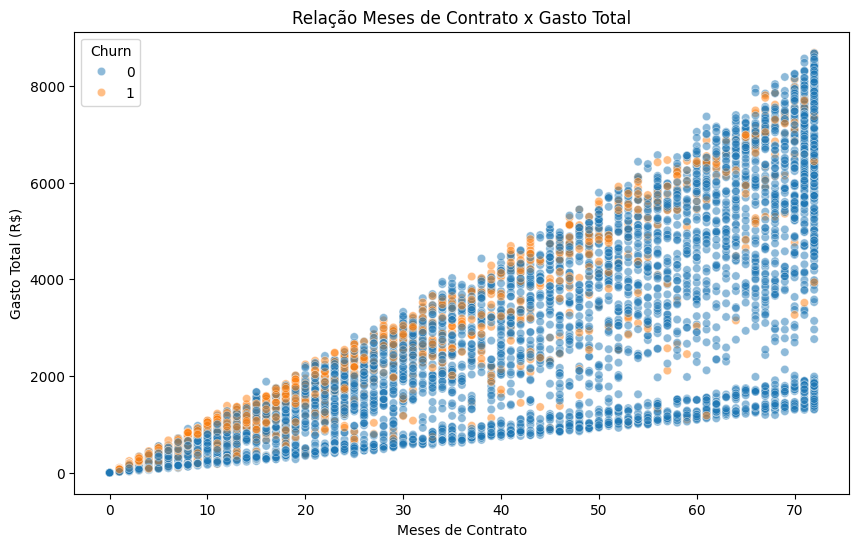

In [176]:
# Gráfico da Relação entre Meses de COntrato e Gasto Total
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Meses de Contrato', y='Gasto Total', hue='Churn', data=dados, alpha=0.5)
plt.title('Relação Meses de Contrato x Gasto Total')
plt.xlabel('Meses de Contrato')
plt.ylabel('Gasto Total (R$)')
plt.show()

# Modelagem Preditiva

## Separação de Dados

In [159]:
dados_tratados

,onehotencoder__Gênero_Male,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__Tipo de Contrato_Month-to-month,onehotencoder__Tipo de Contrato_One year,onehotencoder__Tipo de Contrato_Two year,onehotencoder__Método de Pagamento_Bank transfer (automatic),onehotencoder__Método de Pagamento_Credit card (automatic),onehotencoder__Método de Pagamento_Electronic check,...,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__StreamingTV,remainder__StreamingMovies,remainder__Conta Digital,remainder__Gasto Mensal,remainder__Gasto Total,remainder__Gasto Diário,Churn
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,65.60,593.30,2.19,0
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,59.90,542.40,2.00,0
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,73.90,280.85,2.46,1
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,98.00,1237.85,3.27,1
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,83.90,267.40,2.80,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,55.15,742.90,1.84,0
7039,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,85.10,1873.70,2.84,1
7040,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,50.30,92.75,1.68,0
7041,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,67.85,4627.65,2.26,0


In [160]:
V_explicativas_utilizar

['onehotencoder__Tipo de Contrato_Month-to-month',
 'onehotencoder__InternetService_Fiber optic',
 'onehotencoder__Método de Pagamento_Electronic check',
 'remainder__Gasto Mensal',
 'remainder__Conta Digital',
 'remainder__Cliente Senior',
 'onehotencoder__Método de Pagamento_Bank transfer (automatic)',
 'onehotencoder__InternetService_DSL',
 'onehotencoder__Método de Pagamento_Credit card (automatic)',
 'remainder__Possui parceiro(a)',
 'remainder__Possui Dependentes',
 'remainder__TechSupport',
 'remainder__OnlineSecurity',
 'onehotencoder__Tipo de Contrato_One year',
 'onehotencoder__InternetService_No',
 'onehotencoder__Tipo de Contrato_Two year',
 'remainder__Meses de Contrato']

In [161]:
V_explicativas_descartadas

['remainder__StreamingTV',
 'remainder__StreamingMovies',
 'remainder__MultipleLines',
 'remainder__PhoneService',
 'onehotencoder__Gênero_Male',
 'remainder__DeviceProtection',
 'remainder__OnlineBackup',
 'onehotencoder__Método de Pagamento_Mailed check',
 'remainder__Gasto Total',
 'remainder__Gasto Diário']

In [162]:
# Recarregar as variáveis com as colunas selecionadas para o estudo
X = dados_tratados[V_explicativas_utilizar]
y = dados_tratados['Churn']

In [163]:
# Atribuir a seleção de Treino e Teste às variáveis
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y)

## Criação de Modelos

### Modelo de Base

In [164]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)

print(round(dummy.score(X_test, y_test),4))

0.7345


### Árvore de descisão

In [165]:
arvore = DecisionTreeClassifier(max_depth = 3)
arvore.fit(X_train, y_train)

print(round(arvore.score(X_test, y_test),4))

0.7918


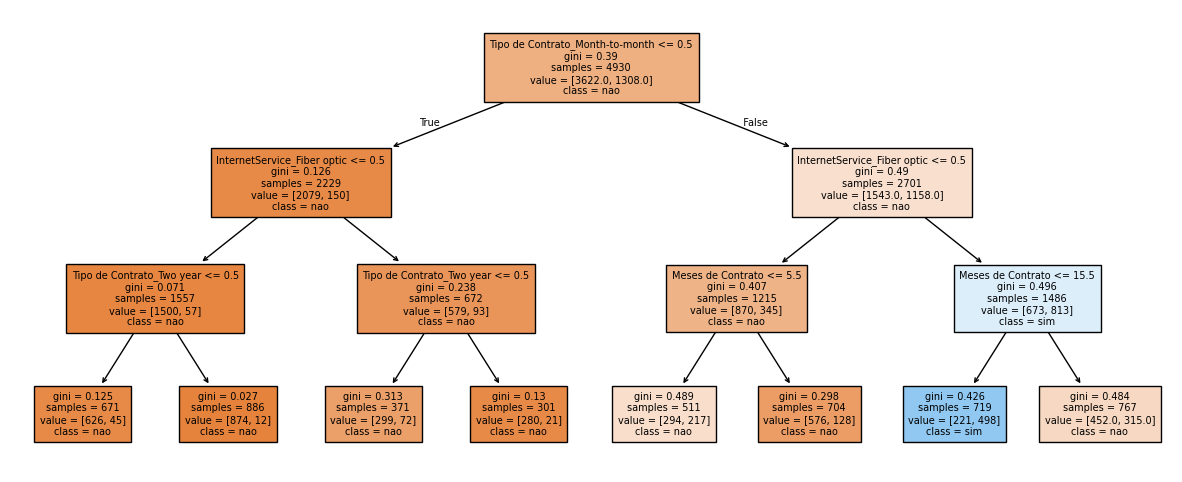

In [183]:
# Nome das colunas mais amigável
nome_colunas = [c.split('__', 1)[1] for c in list(X_train.columns)]

# Gráfico da Árvore de descisão
plt.figure(figsize = (15, 6))
plot_tree(arvore, filled = True, class_names = ['nao', 'sim'], fontsize = 7, feature_names = nome_colunas);

### Random Forest

In [224]:
model_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',max_depth=8)
model_rf.fit(X_train, y_train)

print(round(model_rf.score(X_test, y_test),4))

0.7496


### KNN

Normalizando os dados

Colunas como Meses de Contrato e Gasto Mensal possuem ampla variedade de valores que precisam ser normalizados para utilização adequada no modelo KNN.

In [189]:
dados_tratados[['remainder__Meses de Contrato','remainder__Gasto Mensal']].describe().round(2)

,remainder__Meses de Contrato,remainder__Gasto Mensal
count,7043.00,7043.00
mean,32.37,64.76
std,24.56,30.09
min,0.00,18.25
25%,9.00,35.50
50%,29.00,70.35
75%,55.00,89.85
max,72.00,118.75


In [190]:
# Normalização
normalizacao = MinMaxScaler()
x_treino_normalizado = normalizacao.fit_transform(X_train)

# Aplicar método KNN
knn = KNeighborsClassifier()
knn.fit(x_treino_normalizado, y_train)

x_teste_normalizado = normalizacao.transform(X_test)
knn.score(x_teste_normalizado, y_test)

## Regressão Logística

In [203]:
log_reg = LogisticRegression(max_iter=1000,class_weight="balanced")
log_reg.fit(x_treino_normalizado, y_train)

log_reg.score(x_teste_normalizado, y_test)

0.7278750591575959

# Otimização de Hiperparâmetros

In [209]:
X_train

,onehotencoder__Tipo de Contrato_Month-to-month,onehotencoder__InternetService_Fiber optic,onehotencoder__Método de Pagamento_Electronic check,remainder__Gasto Mensal,remainder__Conta Digital,remainder__Cliente Senior,onehotencoder__Método de Pagamento_Bank transfer (automatic),onehotencoder__InternetService_DSL,onehotencoder__Método de Pagamento_Credit card (automatic),remainder__Possui parceiro(a),remainder__Possui Dependentes,remainder__TechSupport,remainder__OnlineSecurity,onehotencoder__Tipo de Contrato_One year,onehotencoder__InternetService_No,onehotencoder__Tipo de Contrato_Two year,remainder__Meses de Contrato
1315,0.0,1.0,0.0,100.05,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,22.0
2894,1.0,1.0,1.0,88.05,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,9.0
5624,1.0,0.0,0.0,81.30,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,45.0
4574,1.0,0.0,0.0,25.00,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,31.0
4813,1.0,0.0,1.0,21.00,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,0.0,0.0,0.0,36.10,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,63.0
6046,0.0,1.0,0.0,107.20,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,69.0
6917,1.0,0.0,0.0,48.55,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,11.0
1399,1.0,1.0,0.0,79.35,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestRegressor was fitted with feature names



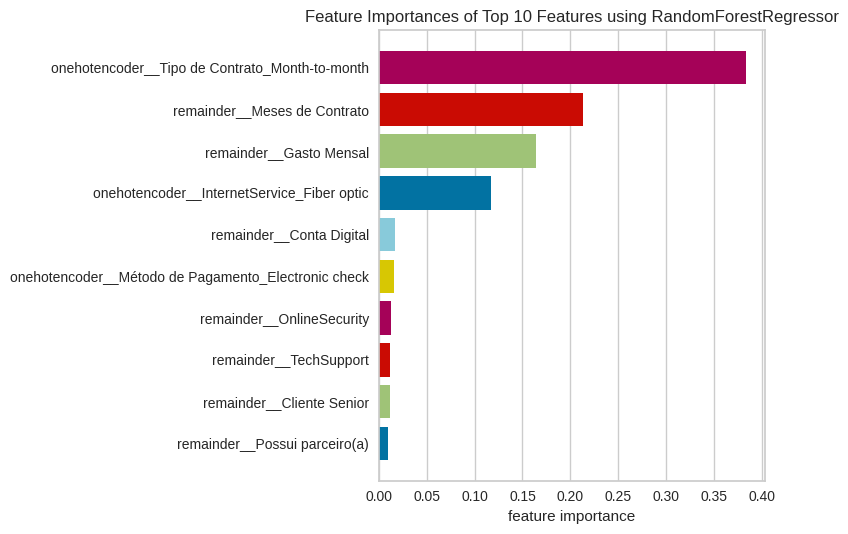

<Axes: title={'center': 'Feature Importances of Top 10 Features using RandomForestRegressor'}, xlabel='feature importance'>

In [195]:
from yellowbrick.model_selection import FeatureImportances

viz = FeatureImportances(model_rf, relative=False, topn=10)
viz.fit(X_train, y_train)
viz.show()

In [196]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calcular_metricas_regressao(y_test, y_pred):

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metricas = {
        'Raiz do Erro Quadrático Médio': round(rmse, 4),
        'Erro Absoluto Médio': round(mae, 4),
        'R2 Score': round(r2, 4)
    }

    return metricas

In [201]:
importances = model_rf.feature_importances_

feature_importances = pd.DataFrame({'Features': X.columns, 'Importances': importances})
feature_importances.sort_values('Importances', ascending=False)

,Features,Importances
0,onehotencoder__Tipo de Contrato_Month-to-month,0.489310
16,remainder__Meses de Contrato,0.205947
1,onehotencoder__InternetService_Fiber optic,0.149229
3,remainder__Gasto Mensal,0.088067
2,onehotencoder__Método de Pagamento_Electronic ...,0.011328
14,onehotencoder__InternetService_No,0.010992
7,onehotencoder__InternetService_DSL,0.009123
4,remainder__Conta Digital,0.006704
12,remainder__OnlineSecurity,0.005526
5,remainder__Cliente Senior,0.005152


In [202]:
# Avaliando o resultado de acordo com a quantidade de features inseridas no modelo
results_df = pd.DataFrame(index=['RMSE', 'MAE', 'R2'])

model_selected_features = RandomForestRegressor(max_depth=5)

for count in [1,5,10,15,20,25,30]:
    selected_features = feature_importances['Features'].values[:count]

    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    model_selected_features.fit(X_train_selected, y_train)

    y_pred = model_selected_features.predict(X_test_selected)

    metricas = calcular_metricas_regressao(y_test, y_pred)

    results_df[count] = list(metricas.values())

results_df

,1,5,10,15,20,25,30
RMSE,0.4048,0.3865,0.3857,0.3811,0.3690,0.3686,0.3688
MAE,0.3279,0.2976,0.2968,0.2927,0.2758,0.2755,0.2753
R2,0.1596,0.2341,0.2372,0.2551,0.3019,0.3034,0.3026


# Comparação das métricas obtidas em cada Modelo

In [214]:
# Função para cálculo das Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def avaliar_modelo(modelo, X_test, y_test):
  y_pred = modelo.predict(X_test)
  return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred,zero_division=0), recall_score(y_test, y_pred), f1_score(y_test, y_pred),confusion_matrix(y_test, y_pred)]

Avalie cada modelo utilizando as seguintes métricas:

Acurácia

Precisão

Recall

F1-score

Matriz de confusão

Em seguida, faça uma análise crítica e compare os modelos:

Qual modelo teve o melhor desempenho?

Algum modelo apresentou overfitting ou underfitting? Se sim, considere as possíveis causas e ajustes:

Overfitting: Quando o modelo aprende demais sobre os dados de treino, perdendo a capacidade de generalizar para novos dados. Considere reduzir a complexidade do modelo ou aumentar os dados de treino.

Underfitting: Quando o modelo não captura bem as tendências dos dados, indicando que está muito simples. Tente aumentar a complexidade do modelo ou ajustar seus parâmetros.

In [228]:
# Cria o DataFrame para armazenar as métricas
Resultados = pd.DataFrame(index=['Acurácia','Precisão','Recall','F1-score','Matriz de Confusão'])

# Obtem as métricas de cada modelo
Resultados['Dummy'] = avaliar_modelo(dummy, X_test, y_test)
Resultados['Árvore de Descisão'] = avaliar_modelo(arvore, X_test, y_test)
Resultados['KNN'] = avaliar_modelo(knn, x_teste_normalizado, y_test)
Resultados['Regressão Logística'] = avaliar_modelo(log_reg, x_teste_normalizado, y_test)
Resultados['Ramdom Forest'] = avaliar_modelo(model_rf, X_test, y_test)

# Emite resultados consolidados
Resultados

,Dummy,Árvore de Descisão,KNN,Regressão Logística,Ramdom Forest
Acurácia,0.734501,0.791765,0.776621,0.727875,0.749645
Precisão,0.0,0.690852,0.589178,0.492408,0.518957
Recall,0.0,0.390374,0.524064,0.809269,0.780749
F1-score,0.0,0.498861,0.554717,0.612272,0.623488
Matriz de Confusão,"[[1552, 0], [561, 0]]","[[1454, 98], [342, 219]]","[[1347, 205], [267, 294]]","[[1084, 468], [107, 454]]","[[1146, 406], [123, 438]]"
